# FashFusion — 전처리 통합 노트북

---

## 프로젝트 개요
- **팀명**: QuadrupleNet
- **모델명**: FashFusion
- **목표**: 장바구니 아이템 조합 → 구매 전환 확률 예측

## 모델 구조

## 사용 데이터
| 데이터 | 용도 | 다운로드 |
|---|---|---|
| Polyvore | 코디 적합도 사전학습 (Stage 1) | https://github.com/xthan/polyvore-dataset |
| Polyvore 이미지 | 상품 이미지 | https://www.kaggle.com/datasets/dnepozitek/maryland-polyvore-images/data |
| H&M | 구매 전환 파인튜닝 (Stage 2) | https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations/data |

- 데이터가 아래 상태로 있어야함
- hnm은 데이터 용량이 커서 캐글 웹사이트에서 받는것 추천...
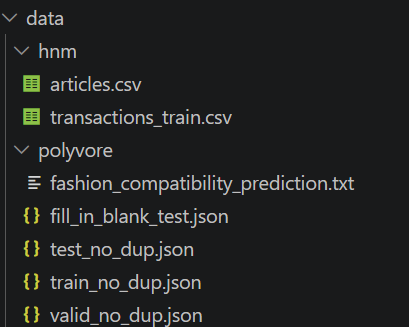

```
[이미지] → MobileNetV2  → img_emb (1280d)
                                        ↓ concat → item_emb
[텍스트] → DistilBERT   → txt_emb (768d)
                                        ↓
                             Late Fusion MLP
                                        ↓
                             구매 전환 확률 (0~1)
```

## 현재 데이터 & 필요한 것
```
bdp/data/
├── hnm/
│   ├── articles.csv             ✅ 보유
│   ├── transactions_train.csv   ✅ 보유
│   └── images/                  ⬇️ 아래 셀에서 다운로드 (34GB)/(캐글에서 직접 다운 받아도됨)  
│       ├── 010/
│       └── ...
└── polyvore/
    ├── train_no_dup.json        ✅ 보유
    ├── valid_no_dup.json        ✅ 보유
    ├── test_no_dup.json         ✅ 보유
    ├── fill_in_blank_test.json  ✅ 보유
    ├── fashion_compatibility_prediction.txt ✅ 보유
    └── images/                  ⬇️ 아래 셀에서 HuggingFace parquet 추출
        └── {item_id}.jpg
```

## 전처리 목표
| 항목 | 처리 방법 |
|---|---|
| 이미지 | 224×224 리사이즈, ImageNet 정규화 (MobileNetV2) |
| 텍스트 | DistilBERT 토크나이징, max_length=128 |
| 결측 이미지 | 데이터셋에서 즉시 제거 |
| Negative Sampling | 같은 카테고리 다른 아이템으로 교체 (label=0) |
| 클래스 불균형 | Stratified K-Fold(K=5) 인덱스 저장 |

---

hnm  사진 articles.csv 없는 데이터 nan 파일 없애기
승한 = hnm 텍스트 전처리
나 - 이미지 없는 거 올려주기 hnm  이미지 , 폴리보어는 구글 들이버 올리기   
지원- lpb, hog, hsv 특징추출-연습

## 라이브러리 설치

In [1]:
!pip install transformers torch torchvision Pillow tqdm scikit-learn kagglehub huggingface_hub datasets

## 라이브러리 import

In [2]:
import json, random, pickle, io, shutil
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from transformers import DistilBertTokenizer
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

random.seed(42)
np.random.seed(42)
print('라이브러리 로드 완료')

c:\Users\renee\anaconda3\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


라이브러리 로드 완료


## 공통 설정

In [3]:
# ── 경로 ────────────────────────────────────────────────────
BASE_DIR      = Path('./data')
POLYVORE_DIR  = BASE_DIR / 'polyvore'
POLYVORE_IMG  = POLYVORE_DIR / 'images'
HNM_DIR       = BASE_DIR / 'hnm'
HNM_IMG       = HNM_DIR / 'images'
OUTPUT_DIR    = Path('./output')

for p in [POLYVORE_IMG, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ── 하이퍼파라미터 ───────────────────────────────────────────
MAX_LENGTH      = 128
IMG_SIZE        = 224
MAX_HNM_OUTFITS = 50_000

# ── 이미지 전처리 (MobileNetV2) ──────────────────────────────
image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ── DistilBERT 토크나이저 ────────────────────────────────────
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(texts):
    enc = tokenizer(
        texts, padding='max_length', truncation=True,
        max_length=MAX_LENGTH, return_tensors='pt'
    )
    return enc['input_ids'], enc['attention_mask']

print(f'설정 완료 | 이미지: {IMG_SIZE}x{IMG_SIZE} | max_length: {MAX_LENGTH}')

설정 완료 | 이미지: 224x224 | max_length: 128


---
# ▼ 데이터 다운로드

---
## [다운로드 1] H&M 이미지 — Kaggle (34GB)
> **사전 준비**: Kaggle 계정 → Settings → API → Create New Token  
> 받은 `kaggle.json`을 `~/.kaggle/kaggle.json` 에 저장 후 실행

In [5]:
if not HNM_IMG.exists() or not any(HNM_IMG.iterdir()):
    import kagglehub
    print('H&M 이미지 다운로드 중... (34GB, 시간 많이 걸림)')
    path = kagglehub.competition_download(
        'h-and-m-personalized-fashion-recommendations'
    )
    src = Path(path) / 'images'
    if src.exists():
        shutil.move(str(src), str(HNM_IMG))
        print(f'완료 → {HNM_IMG}')
    else:
        print(f'images 폴더를 수동으로 {HNM_IMG} 에 복사하세요')
else:
    print(f'H&M 이미지 이미 존재 → {HNM_IMG}')

H&M 이미지 이미 존재 → data\hnm\images


## [다운로드 2] Polyvore 이미지 — HuggingFace parquet에서 추출 (4.3GB)
> **사전 준비**: https://huggingface.co/datasets/mvasil/polyvore-outfits 에서 Access Request 승인 받기  
> 터미널에서 `huggingface-cli login` 실행 후 토큰 입력 (토큰: https://huggingface.co/settings/tokens)

In [ ]:
import os, json

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

creds = {"username":"reneejoo","key":""}  # key 전체 붙여넣기
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(creds, f)

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('완료')

완료


In [16]:
if not POLYVORE_IMG.exists() or not any(POLYVORE_IMG.iterdir()):
    from datasets import load_dataset

    print('HuggingFace에서 Polyvore parquet 로드 중... (4.3GB)')
    ds = load_dataset('mvasil/polyvore-outfits', 'disjoint', token="hf_yau...")

    print('이미지 추출 & 저장 중...')
    saved = 0
    for split in ['train', 'validation', 'test']:
        for row in tqdm(ds[split], desc=f'  {split}'):
            item_id  = str(row['item_id'])
            img_data = row.get('image')
            if img_data is None: continue
            out_path = POLYVORE_IMG / f'{item_id}.jpg'
            if out_path.exists(): continue
            if isinstance(img_data, bytes):
                img = Image.open(io.BytesIO(img_data)).convert('RGB')
            elif isinstance(img_data, dict):
                img = Image.open(io.BytesIO(img_data['bytes'])).convert('RGB')
            else:
                img = img_data.convert('RGB')
            img.save(out_path, 'JPEG')  # ← 저장
            saved += 1                  # ← 카운트

    print(f'완료 → {saved:,}개 저장 → {POLYVORE_IMG}')
else:
    print(f'Polyvore 이미지 이미 존재 → {POLYVORE_IMG}')

HuggingFace에서 Polyvore parquet 로드 중... (4.3GB)


Using the latest cached version of the dataset since mvasil/polyvore-outfits couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'disjoint' at C:\Users\renee\.cache\huggingface\datasets\mvasil___polyvore-outfits\disjoint\0.0.0\22cc0c748c293a598e1df561a76abe96273cb76a (last modified on Wed Apr 22 12:14:56 2026).


이미지 추출 & 저장 중...


  test: 100%|██████████| 70035/70035 [03:12<00:00, 364.75it/s]

완료 → 152,785개 저장 → data\polyvore\images


---
# ① POLYVORE 전처리 (Stage 1 — 코디 적합도 사전학습)

---
## [Polyvore] STEP 1 — JSON 로드 & 아이템 ID 생성
`set_id + index` → `set_id_index` 고유 ID  
 어느 세트의 몇 번째 아이템인지로 ID를 만든 것

 [추가 설명]  
 - outfit 이란 어울리는 옷 세트를 적은 json 형태의 데이터
    - 예시 : [흰 스웨트셔츠, 청바지, 가죽 부츠] -> 이게 하나의 outfit
- item 이란 FashFusion\data\polyvore\images 경로에 있는 개별의 이미지들 데이터

In [9]:
def load_outfits(path):
    with open(path, 'r') as f:
        return json.load(f)

def parse_items(outfits):
    rows = []
    for outfit in outfits:
        set_id = outfit['set_id']
        for item in outfit.get('items', []):
            rows.append({
                'item_id'    : f"{set_id}_{item['index']}",
                'set_id'     : set_id,
                'name'       : item.get('name', ''),
                'categoryid' : item.get('categoryid', -1),
            })
    return pd.DataFrame(rows)

poly_outfits = load_outfits(POLYVORE_DIR / 'train_no_dup.json')
poly_items   = parse_items(poly_outfits)
print(f'outfit: {len(poly_outfits):,}개 / item: {len(poly_items):,}개')
poly_items.head(3)

outfit: 17,316개 / item: 114,806개


,item_id,set_id,name,categoryid
0,214181831_1,214181831,mock neck embroidery suede sweatshirt,4495
1,214181831_2,214181831,luxe double zip hooded jacket,25
2,214181831_3,214181831,citizens humanity high rise rocket hem jean,27


아이템 2개 이상 outfit: 5677개
Index(['100095342', '100176564', '100302025', '100346741', '100786280'], dtype='object', name='set_id')
아이템 2개 발견


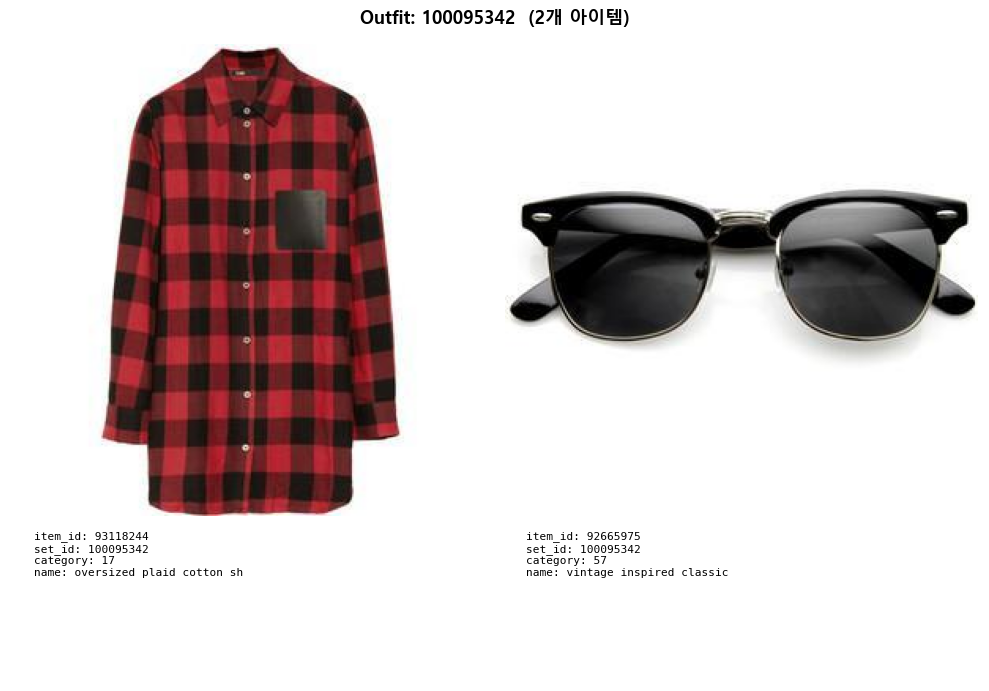

In [30]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import matplotlib.font_manager as fm

# 윈도우 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def show_outfit(set_id):
    items = poly_items[poly_items['set_id'] == str(set_id)].reset_index(drop=True)
    n = len(items)
    print(f'아이템 {n}개 발견')  # 몇 개 찾았는지 확인용
    
    if n == 0:
        print('해당 set_id의 아이템이 없어요!')
        return
    
    fig = plt.figure(figsize=(5 * n, 7))
    gs = gridspec.GridSpec(2, n, height_ratios=[3, 1])
    
    for i, (_, row) in enumerate(items.iterrows()):
        # 위쪽: 이미지
        ax_img = fig.add_subplot(gs[0, i])
        img_path = POLYVORE_IMG / f"{row['item_id']}.jpg"
        if img_path.exists():
            img = Image.open(img_path).convert('RGB')
            ax_img.imshow(img)
        else:
            ax_img.text(0.5, 0.5, '이미지 없음', ha='center', va='center', fontsize=10)
        ax_img.axis('off')
        
        # 아래쪽: 메타데이터
        ax_txt = fig.add_subplot(gs[1, i])
        ax_txt.axis('off')
        meta = (
            f"item_id: {row['item_id']}\n"
            f"set_id: {row['set_id']}\n"
            f"category: {row['categoryid']}\n"
            f"name: {row['name'][:25]}"
        )
        ax_txt.text(0.05, 0.95, meta, va='top', ha='left',
                    fontsize=8, family='monospace',
                    transform=ax_txt.transAxes)
    
    plt.suptitle(f'Outfit: {set_id}  ({n}개 아이템)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# set_id 확인 후 테스트
# 이미지 있는 아이템이 2개 이상인 outfit 찾기
valid_items = poly_items[poly_items['item_id'].isin(valid_poly_ids)]
outfit_counts = valid_items.groupby('set_id').size()
multi_item_outfits = outfit_counts[outfit_counts >= 2].index

print(f'아이템 2개 이상 outfit: {len(multi_item_outfits)}개')
print(multi_item_outfits[:5])  # set_id 5개 출력

# 그 중 첫 번째로 테스트
show_outfit(multi_item_outfits[0])

### [Polyvore] STEP 2 — 텍스트 토크나이징 (DistilBERT)
- 이 부분은 생략함

In [ ]:
texts      = poly_items['name'].tolist()
ids, masks = tokenize(texts)
torch.save({'input_ids': ids, 'attention_mask': masks},
           OUTPUT_DIR / 'poly_text_tokens.pt')
print(f'shape: {ids.shape} → 저장 완료')

shape: torch.Size([114806, 128]) → 저장 완료


## [Polyvore] STEP 3 — 이미지 전처리 (MobileNetV2)
경로: `polyvore/images/{item_id}.jpg` | 결측 이미지 즉시 제거

In [ ]:
# 
def parse_items(outfits):
    rows = []
    for outfit in outfits:
        set_id = outfit['set_id']
        for item in outfit.get('items', []):
            # URL에서 tid 숫자(이미지 데이터의 파일명) 추출
            image_url = item.get('image', '')
            tid = image_url.split('tid=')[-1] if 'tid=' in image_url else None
            if tid is None:
                continue
            rows.append({
                'item_id'    : tid,          # ← 100005237 형식.  URL에서 진짜 파일명 추출해서 수정
                'set_id'     : set_id,
                'name'       : item.get('name', ''),
                'categoryid' : item.get('categoryid', -1),
            })
    return pd.DataFrame(rows)

poly_outfits = load_outfits(POLYVORE_DIR / 'train_no_dup.json')
poly_items   = parse_items(poly_outfits)
print(poly_items['item_id'].iloc[0])  # 숫자만 나와야 함
print(f'outfit: {len(poly_outfits):,}개 / item: {len(poly_items):,}개')

194508109
outfit: 17,316개 / item: 114,806개


이미지 전처리 진행
- 224×224로 리사이즈
- 숫자 배열로 변환 (0~1)
- ImageNet 기준으로 정규화
-  poly_image_tensors.pt 저장

In [ ]:

poly_image_tensors = {}
valid_poly_ids     = set()

for item_id in tqdm(poly_items['item_id'], desc='Polyvore 이미지'):
    img_path = POLYVORE_IMG / f'{item_id}.jpg'
    if not img_path.exists(): continue
    t = image_transform(Image.open(img_path).convert('RGB'))
    poly_image_tensors[item_id] = t
    valid_poly_ids.add(item_id)

poly_items = poly_items[poly_items['item_id'].isin(valid_poly_ids)].reset_index(drop=True)
torch.save(poly_image_tensors, OUTPUT_DIR / 'poly_image_tensors.pt')
print(f'이미지: {len(poly_image_tensors):,}개 | 유효 아이템: {len(poly_items):,}개')

Polyvore 이미지: 100%|██████████| 114806/114806 [06:06<00:00, 313.22it/s] 


이미지: 14,805개 | 유효 아이템: 22,408개


- 전체 아이템(FashFusion\data\polyvore\images)은 114,806개  
- 실제 이미지 파일 있는 것: 14,805개  ← 이미지 개수
- 그 이미지를 가진 아이템 행: 22,408개 ← 유효 아이템 개수
    - "파일 수 < 아이템 수" 인 이유는 같은 아이템이 여러 아웃핏에서 사용되어서
        - 예시 : outfit1 :[흰티, 청바지, 까만 운동화]  
                outfit2 :[흰티, 츄리닝, 샌들]   
                이렇게 같은 아이템인 "흰티"가 2개의 아웃풋에서 사용됨 
---
전처리된 파일은 output 폴더에 저장됨
1. poly_image_tensors.pt
    - 전처리된 14,805개의 이미지
    - Resize → ToTensor → Normalize 3단계 처리 완료
2. poly_text_tokens.pt
    - 각 아이템의 상품명(name)을 DistilBERT로 토크나이징한 결과
    - 이거는 필요하시면 사용하시고 필요 없으시다면 빼셔도 됩니다~
        - 예시: "vans authentic black mono" → 숫자 ID 배열로 변환
        - 114,806개 아이템 전체 기준 (이미지 필터링 전)

---
# ② H&M 전처리 (Stage 2 — 구매 전환 파인튜닝)

---
## [H&M] STEP 1 — 거래 데이터 로드 & 같은 날 구매 묶기
- 왜 이렇게 하나요?
    - 예시
        - 고객A  2020-01-01  [청바지, 흰티, 운동화]  ← 같은날 구매
        - 고객A  2020-01-15  [원피스, 샌들]          ← 같은날 구매
        - 같은 날 같은 사람이 산 것들을 하나의 outfit으로 보는 것  !!

In [ ]:
# 1. transactions_train.csv (구매 기록 전체) 불러오기  
tx = pd.read_csv(HNM_DIR / 'transactions_train.csv',
                 parse_dates=['t_dat'], nrows=5_000_000)

# 2. 고객ID + 날짜 기준으로 묶기
outfits = (
    tx.groupby(['customer_id', 't_dat'])['article_id']
    .apply(list).reset_index()
    .rename(columns={'article_id': 'item_ids'})
)
# 3. 2개 이상 산 것만 outfit으로 인정
outfits = outfits[outfits['item_ids'].apply(len) >= 2].reset_index(drop=True)
if len(outfits) > MAX_HNM_OUTFITS:
    outfits = outfits.sample(n=MAX_HNM_OUTFITS, random_state=42).reset_index(drop=True)

# 4. 50,000개 outfit 추출 완료 
print(f'유효 outfit: {len(outfits):,}개')

유효 outfit: 50,000개


-- 텍스트라서 생략 --  
[H&M] STEP 2 — 상품 텍스트 합치기 + TPO 키워드 추출

In [ ]:
# articles = pd.read_csv(HNM_DIR / 'articles.csv')

# TPO_KEYWORDS = ['casual','formal','sport','outdoor','office',
#                 'party','beach','summer','winter','evening']

# def extract_tpo(text):
#     if not isinstance(text, str): return ''
#     found  = [kw for kw in TPO_KEYWORDS if kw in text.lower()]
#     return (' '.join(found) + ' ' if found else '') + text

# articles['text'] = (
#     articles['product_type_name'].fillna('') + ' ' +
#     articles['colour_group_name'].fillna('') + ' ' +
#     articles['section_name'].fillna('')      + ' ' +
#     articles['detail_desc'].apply(extract_tpo)
# ).str.strip()

# article_text = articles.set_index('article_id')['text'].to_dict()
# print(f'상품: {len(articles):,}개')
# print(f'샘플: {list(article_text.values())[0][:100]}...')

-- 텍스트라서 생략 --  
[H&M] STEP 3 — DistilBERT 토크나이징

In [ ]:
# used_ids = list(set(aid for ids in outfits['item_ids']
#                     for aid in ids if aid in article_text))
# print(f'토크나이징: {len(used_ids):,}개')

# BATCH = 512
# hnm_token_dict = {}
# for i in tqdm(range(0, len(used_ids), BATCH), desc='H&M 토크나이징'):
#     batch_ids   = used_ids[i:i+BATCH]
#     batch_texts = [article_text[aid] for aid in batch_ids]
#     ids, masks  = tokenize(batch_texts)
#     for j, aid in enumerate(batch_ids):
#         hnm_token_dict[aid] = {'input_ids': ids[j], 'attention_mask': masks[j]}

# torch.save(hnm_token_dict, OUTPUT_DIR / 'hnm_text_tokens.pt')
# print('저장 완료')

## [H&M] STEP 4 — 이미지 전처리 (MobileNetV2)
경로: `hnm/images/{앞3자리}/{article_id}.jpg` | 결측 이미지 즉시 제거



In [32]:
hnm_image_tensors = {}
valid_hnm_ids     = set()

# 1. 50,000개 outfit 안에 있는 아이템들
used_ids = list(set(aid for ids in outfits['item_ids'] for aid in ids))
print(f'사용된 아이템: {len(used_ids):,}개')

# 2. 그 아이템들 이미지 파일 찾기
for aid in tqdm(used_ids, desc='H&M 이미지'):
    aid_str  = str(aid).zfill(10)
    img_path = HNM_IMG / aid_str[:3] / f'{aid_str}.jpg'
    if not img_path.exists(): continue
    # 3. Resize → ToTensor → Normalize 
    t = image_transform(Image.open(img_path).convert('RGB'))
    hnm_image_tensors[aid] = t
    valid_hnm_ids.add(aid)

outfits['item_ids'] = outfits['item_ids'].apply(
    lambda ids: [x for x in ids if x in valid_hnm_ids]
)
outfits = outfits[outfits['item_ids'].apply(len) >= 2].reset_index(drop=True)

# 4. hnm_image_tensors.pt 저장
torch.save(hnm_image_tensors, OUTPUT_DIR / 'hnm_image_tensors.pt')
print(f'이미지: {len(hnm_image_tensors):,}개 | 유효 outfit: {len(outfits):,}개')

사용된 아이템: 26,025개


H&M 이미지: 100%|██████████| 26025/26025 [45:20<00:00,  9.57it/s]  


이미지: 25,833개 | 유효 outfit: 49,831개


---
## 최종 파일 목록 확인

In [33]:
print('=== 생성된 파일 ===')
for f in sorted(OUTPUT_DIR.iterdir()):
    stage = 'Stage1 (Polyvore)' if 'poly' in f.name else 'Stage2 (H&M)'
    print(f'  [{stage}] {f.name:40s} {f.stat().st_size/1e6:.1f} MB')
print('\n✅ 전처리 완료!')

=== 생성된 파일 ===
  [Stage2 (H&M)] hnm_image_tensors.pt                     15562.1 MB
  [Stage1 (Polyvore)] poly_image_tensors.pt                    8918.9 MB
  [Stage1 (Polyvore)] poly_text_tokens.pt                      235.1 MB

✅ 전처리 완료!
